In [39]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/ethiopia.csv")
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df.describe()
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["month"] = df["date"].dt.month
df[["YEAR", "DOY", "date", "month"]].head()
df.head()




,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1


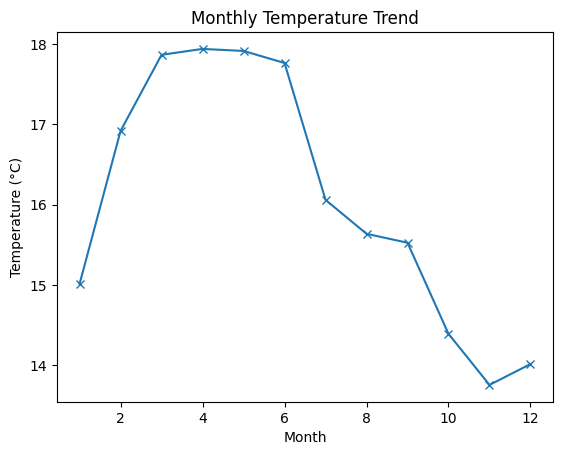

In [ ]:
import matplotlib.pyplot as plt

df.groupby("month")["T2M"].mean().plot(marker="x")
plt.title("This graph shows monthly temperature changes")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

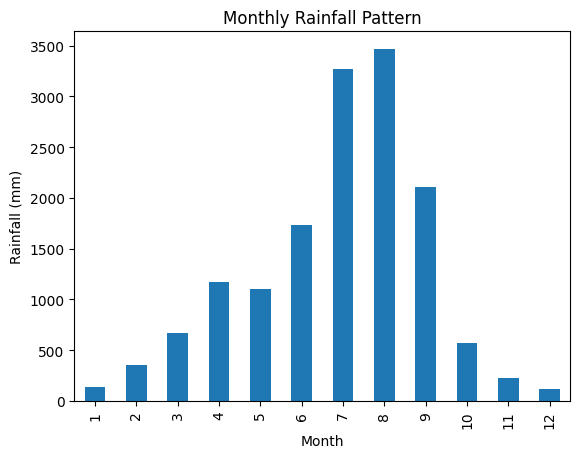

In [42]:
df.groupby("month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall Pattern")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

In [ ]:
from scipy import stats
import numpy as np

df["z_temp"] = np.abs(stats.zscore(df["T2M"]))
outliers = df[df["z_temp"] > 3]

outliers.shape
outliers[["YEAR", "DOY", "T2M"]]

NameError: name 'rain_outliers' is not defined